In [1]:
import numpy as np
import matplotlib.pyplot as plt
import legume
from legume import Circle, Ring

# L3 Cavity with Oxidized Holes
Optimized L3 cavity (GaAs, end-hole shift from autograd optimization) with
thin oxide rings on hole sidewalls. Sweeps oxide thickness to study effect on Q.

Bandgap: 0.2489 – 0.3274,  centre f_target = 0.2882


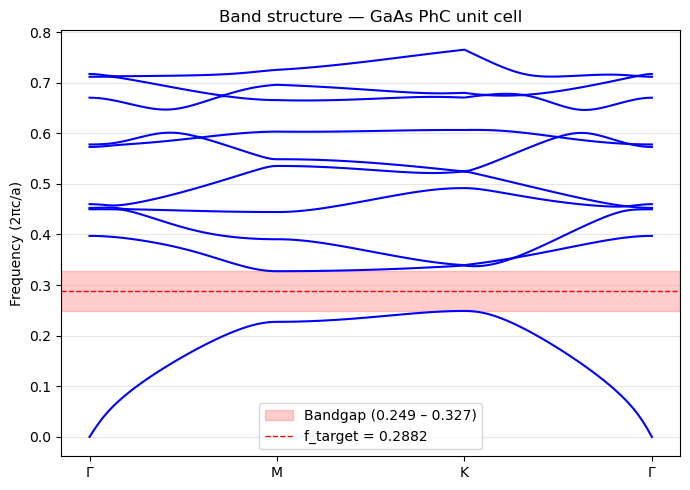

In [2]:
# ── Band structure of the perfect PhC (unit cell) ──────────────────────────

# ── Physical parameters ─────────────────────────────────────────────────────
a_nm = 250              # lattice constant in nm
ra = 75 / a_nm          # hole radius in units of a
dslab = 170 / a_nm      # slab thickness in units of a
n_slab = 3.46           # refractive index (GaAs)

lattice_unit = legume.Lattice('hexagonal')
phc_unit = legume.PhotCryst(lattice_unit)
phc_unit.add_layer(d=dslab, eps_b=n_slab**2)
phc_unit.add_shape(Circle(x_cent=0, y_cent=0, r=ra))

path_dict = lattice_unit.bz_path(['G', 'M', 'K', 'G'], [40, 40, 40])
kpoints = path_dict['kpoints']

gme_bands = legume.GuidedModeExp(phc_unit, gmax=3.0, truncate_g='tbt')
gme_bands.run(kpoints=kpoints, gmode_inds=[0], verbose=False, numeig=10)

# Find the largest complete bandgap
freqs_b = gme_bands.freqs
f_lb, f_ub, f_target = None, None, None
best_gap = 0
for i in range(freqs_b.shape[1] - 1):
    top = np.max(freqs_b[:, i])
    bot = np.min(freqs_b[:, i + 1])
    if bot > top and (bot - top) > best_gap:
        best_gap = bot - top
        f_lb, f_ub = top, bot
        f_target = (top + bot) / 2

print(f'Bandgap: {f_lb:.4f} \u2013 {f_ub:.4f},  centre f_target = {f_target:.4f}')

# Plot band structure
fig, ax = plt.subplots(figsize=(7, 5))
for i in range(freqs_b.shape[1]):
    ax.plot(freqs_b[:, i], 'b-', lw=1.5)
ax.axhspan(f_lb, f_ub, alpha=0.2, color='red',
           label=f'Bandgap ({f_lb:.3f} \u2013 {f_ub:.3f})')
ax.axhline(f_target, color='red', ls='--', lw=1,
           label=f'f_target = {f_target:.4f}')
ax.set_xticks([0, 40, 80, 120])
ax.set_xticklabels(['\u0393', 'M', 'K', '\u0393'])
ax.set_ylabel('Frequency (2\u03c0c/a)')
ax.set_title('Band structure \u2014 GaAs PhC unit cell')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [3]:
# ── Supercell parameters ───────────────────────────────────────────────────
Nx, Ny = 16, 10

# Oxide material
n_oxide = 1.72
eps_oxide = n_oxide**2

# Initialize supercell lattice
lattice = legume.Lattice([Nx, 0], [0, Ny*np.sqrt(3)/2])

# Build hole positions in one quadrant (L3: skip ix=0,1 at iy=0)
xp, yp = [], []
nx, ny = Nx//2 + 1, Ny//2 + 1
for iy in range(ny):
    for ix in range(nx):
        if iy == 0 and ix in (0, 1):
            continue
        xp.append(ix + (iy%2)*0.5)
        yp.append(iy*np.sqrt(3)/2)

nc = len(xp)

# Optimized end-hole shift (from autograd optimization notebook)
dx_opt = 0.17964
dx = np.zeros(nc)
dy = np.zeros(nc)
dx[0] = dx_opt  # ic=0 → end holes at (±2, 0)

print(f'nc = {nc} holes per quadrant')
print(f'Optimized end-hole shift: dx[0] = {dx_opt}a = {dx_opt * a_nm:.1f} nm')

nc = 52 holes per quadrant
Optimized end-hole shift: dx[0] = 0.17964a = 44.9 nm


In [4]:
import os
from datetime import datetime

SAVE_DATA = True

def save_sweep(name, arrays_dict, **extra_params):
    """Save sweep results to a timestamped folder in data/.

    Parameters
    ----------
    name : str
        Short sweep name (used in folder name).
    arrays_dict : dict
        {label: np.array} — each array is saved as a .npy file.
    **extra_params :
        Sweep-specific parameters to log in info.txt.
    """
    if not SAVE_DATA:
        return
    timestamp = datetime.now().strftime('%Y-%m-%d_%H%M%S')
    folder = os.path.join('data', f'{timestamp}_{name}')
    os.makedirs(folder, exist_ok=True)

    # Save arrays
    for label, arr in arrays_dict.items():
        np.save(os.path.join(folder, f'{label}.npy'), np.asarray(arr))

    # Write info.txt
    with open(os.path.join(folder, 'info.txt'), 'w') as f:
        f.write(f'Sweep: {name}\n')
        f.write(f'Date: {timestamp}\n\n')

        f.write('--- Physical parameters ---\n')
        f.write(f'a_nm = {a_nm}\n')
        f.write(f'ra = {ra:.4f} ({ra * a_nm:.1f} nm)\n')
        f.write(f'dslab = {dslab:.4f} ({dslab * a_nm:.1f} nm)\n')
        f.write(f'n_slab = {n_slab}\n')
        f.write(f'n_oxide = {n_oxide}\n')
        f.write(f'eps_oxide = {eps_oxide:.4f}\n\n')

        f.write('--- Supercell ---\n')
        f.write(f'Nx = {Nx}, Ny = {Ny}\n')
        f.write(f'nc = {nc}\n')
        f.write(f'dx_opt = {dx_opt} ({dx_opt * a_nm:.1f} nm)\n\n')

        f.write('--- GME settings ---\n')
        f.write(f'gmax = {gmax}\n')
        f.write(f'truncate_g = {truncate_g}\n')
        f.write(f'numeig = 10\n')
        f.write(f'gmode_inds = [0]\n\n')

        f.write('--- Bandgap ---\n')
        f.write(f'f_lb = {f_lb:.6f}\n')
        f.write(f'f_ub = {f_ub:.6f}\n')
        f.write(f'f_target = {f_target:.6f}\n')
        f.write(f'f_base = {f_base:.6f}\n')
        f.write(f'Q_base = {Q_base:.1f}\n\n')

        f.write('--- Sweep-specific parameters ---\n')
        for k, v in extra_params.items():
            f.write(f'{k} = {v}\n')

        f.write(f'\n--- Saved arrays ---\n')
        for label in arrays_dict:
            f.write(f'{label}.npy\n')

    print(f'Results saved to {folder}/')

In [6]:
def cavity_oxidized(t_ox_nm, consume_ratio=0.5, r_nm=None, dx_shift=None):
    """Build an L3 cavity with oxide on ALL exposed surfaces.

    Oxide grows both into the GaAs (consuming it) and outward (adding volume).
    The consume_ratio controls the split, applied to both top/bottom surfaces
    and hole sidewalls.

    Parameters
    ----------
    t_ox_nm : float
        Total oxide thickness in nm. Set to 0 for unoxidized cavity.
    consume_ratio : float, optional
        Fraction of oxide that replaces GaAs (0 to 1). Default 0.5.
        0 = all oxide added as extra volume (no GaAs consumed).
        1 = all oxide replaces GaAs (no extra volume added).
    r_nm : float or None, optional
        Hole radius in nm. If None, uses the global `ra` (75 nm default).
    dx_shift : float or None, optional
        End-hole shift in units of a. If None, uses the global `dx_opt`.
    """
    t_ox = t_ox_nm / a_nm  # nm → normalized units
    r_a = (r_nm / a_nm) if r_nm is not None else ra

    dx_local = dx.copy()
    if dx_shift is not None:
        dx_local[0] = dx_shift

    if t_ox_nm > 0:
        d_consume = consume_ratio * t_ox
        d_slab_eff = dslab - 2 * d_consume
        if d_slab_eff <= 0:
            raise ValueError(
                f'Oxide consumes entire slab: 2*{consume_ratio}*{t_ox_nm} nm '
                f'>= dslab = {dslab * a_nm} nm')
        r_outer = r_a + consume_ratio * t_ox
        r_inner = r_a - (1 - consume_ratio) * t_ox
    else:
        d_slab_eff = dslab

    phc = legume.PhotCryst(lattice)

    if t_ox_nm > 0:
        # Layer 0: bottom oxide film
        phc.add_layer(d=t_ox, eps_b=eps_oxide)
        # Layer 1: thinned GaAs slab
        phc.add_layer(d=d_slab_eff, eps_b=n_slab**2)
        # Layer 2: top oxide film
        phc.add_layer(d=t_ox, eps_b=eps_oxide)
    else:
        # No oxide: single slab layer (layer 0)
        phc.add_layer(d=dslab, eps_b=n_slab**2)

    slab_idx = 1 if t_ox_nm > 0 else 0

    for ic in range(nc):
        yc = yp[ic]
        xc = xp[ic] + dx_local[ic] if xp[ic] != 0 else 0.0

        positions = [(xc, yc)]
        if nx-0.6 > xp[ic] > 0 and (ny-1.1)*np.sqrt(3)/2 > yp[ic] > 0:
            positions.append((-xc, -yc))
        if nx-1.6 > xp[ic] > 0:
            positions.append((-xc, yc))
        if (ny-1.1)*np.sqrt(3)/2 > yp[ic] > 0 and nx-1.1 > xp[ic]:
            positions.append((xc, -yc))

        for (px, py) in positions:
            if t_ox_nm > 0:
                # Slab layer: oxide ring (consumes GaAs + grows into air)
                phc.add_shape(Ring(eps=eps_oxide, r_i=r_inner, r_o=r_outer,
                                  x_cent=px, y_cent=py), layer=slab_idx)
                phc.add_shape(Circle(eps=1.0, r=r_inner,
                                    x_cent=px, y_cent=py), layer=slab_idx)
                # Oxide layers: air holes punch through
                phc.add_shape(Circle(eps=1.0, r=r_outer,
                                    x_cent=px, y_cent=py), layer=0)
                phc.add_shape(Circle(eps=1.0, r=r_outer,
                                    x_cent=px, y_cent=py), layer=2)
            else:
                phc.add_shape(Circle(x_cent=px, y_cent=py, r=r_a))

    return phc

## Visualize structure

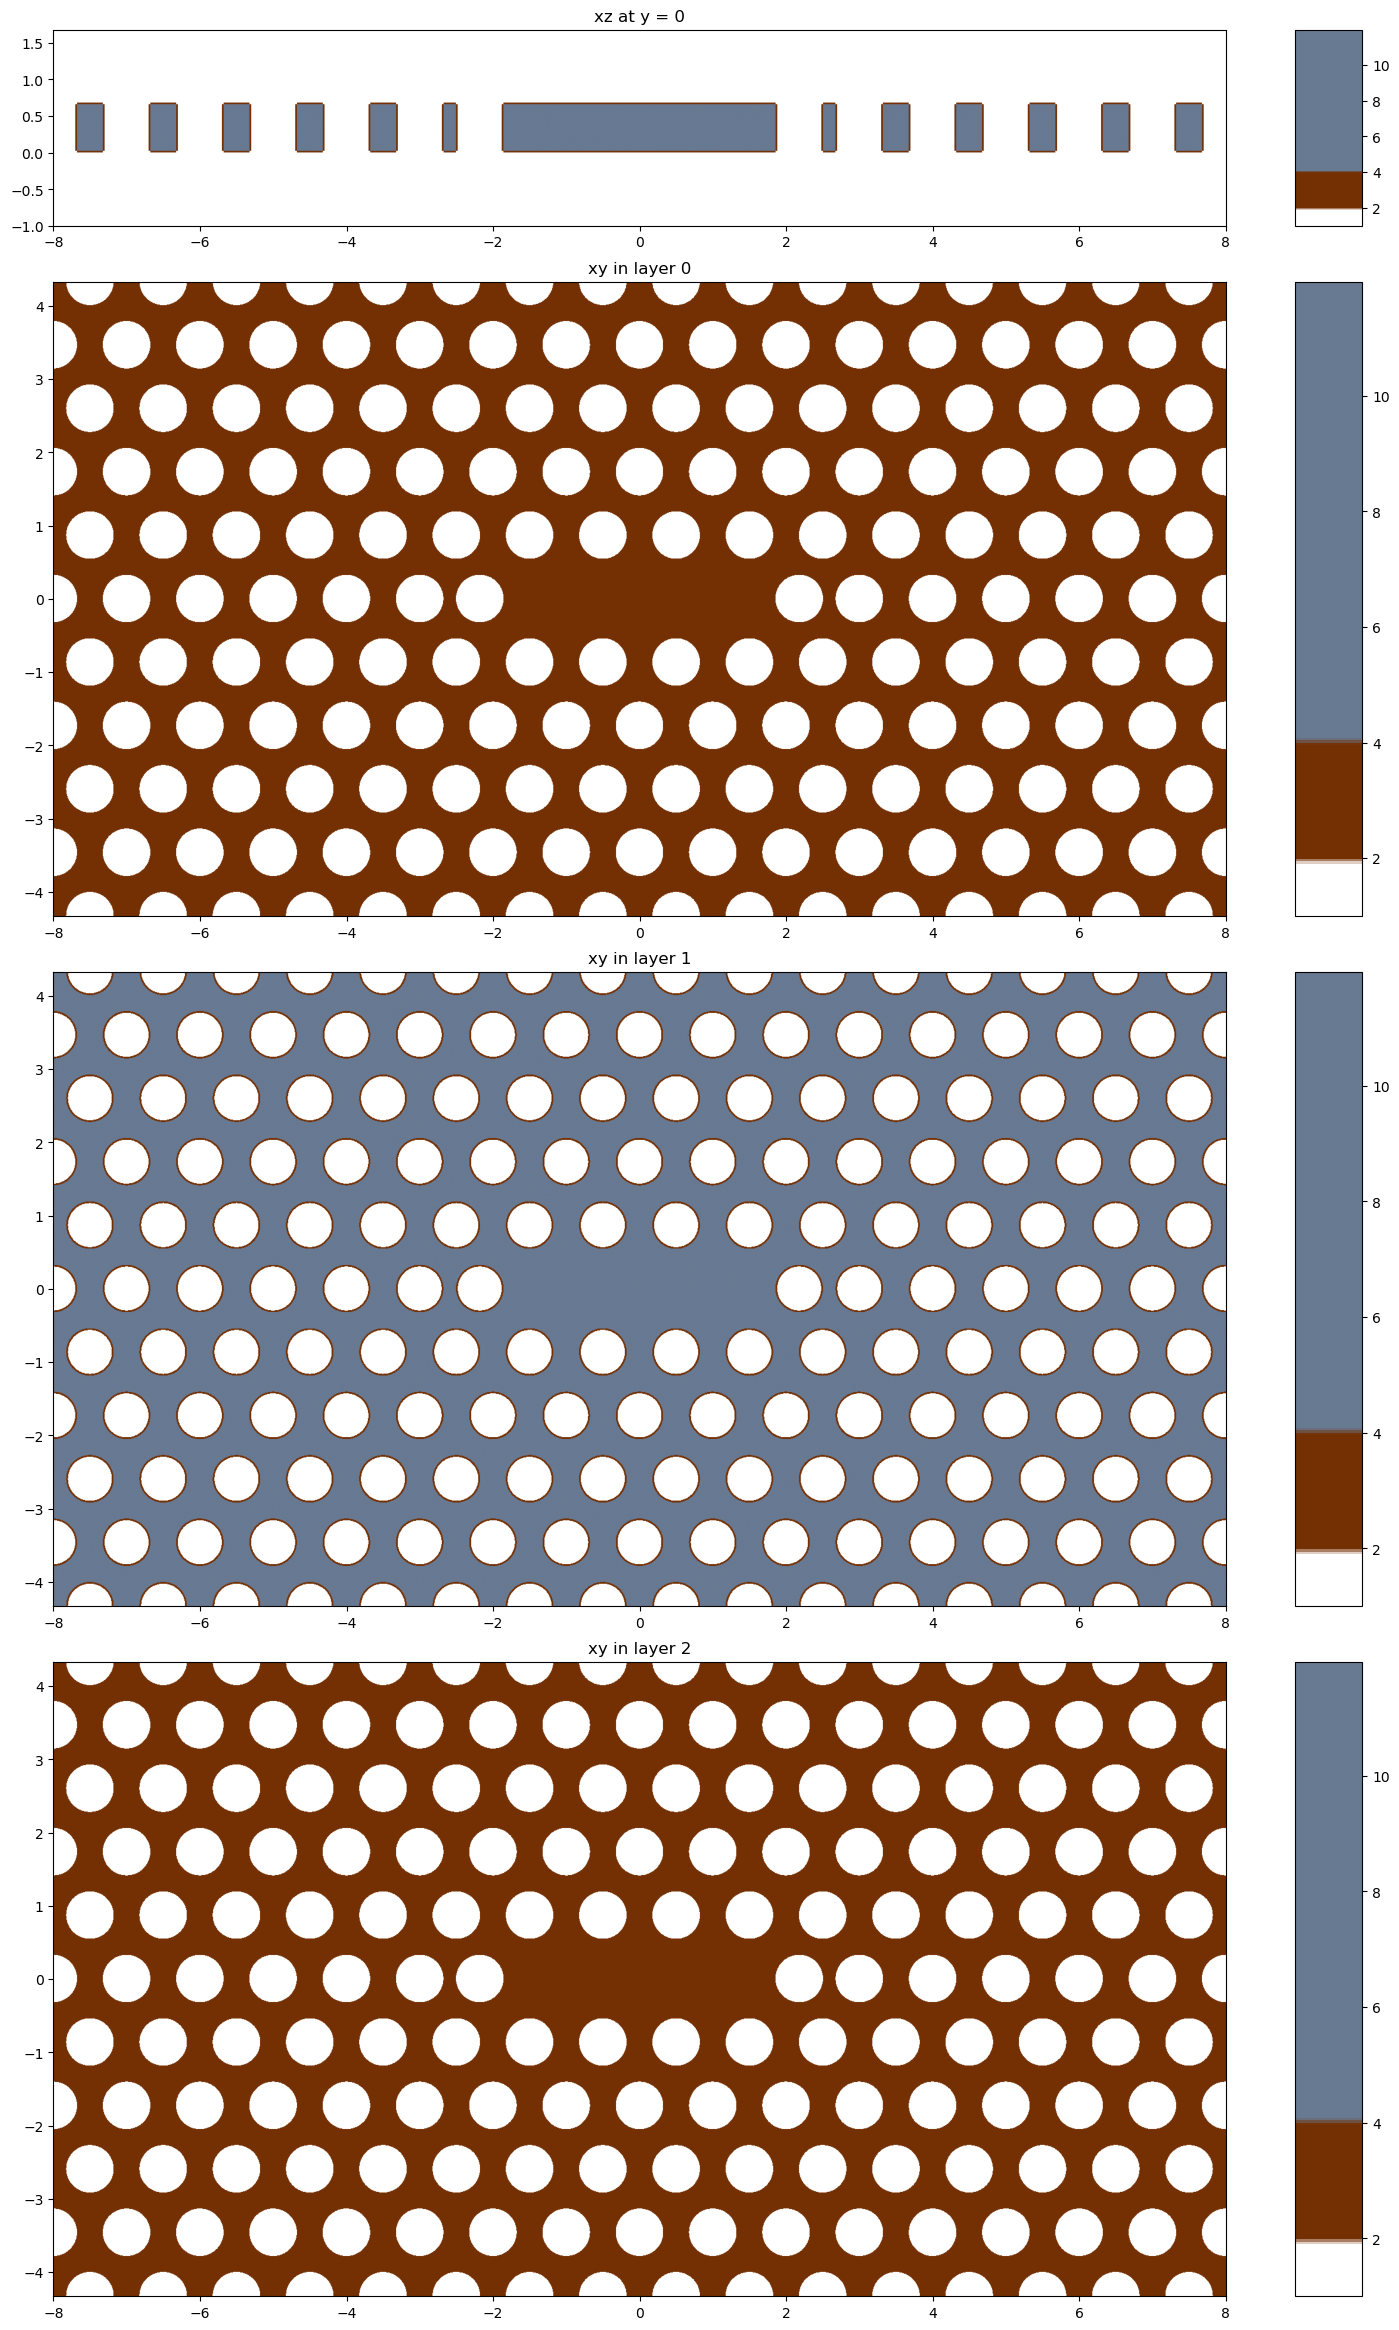

In [7]:
# Visualize the oxidized cavity (t_ox = 5 nm)
phc_viz = cavity_oxidized(6, consume_ratio=1.0)
gme_viz = legume.GuidedModeExp(phc_viz, gmax=2, truncate_g='tbt')

# Discrete colormap: air=white, oxide=gold, GaAs=dark blue
# eps values: air=1.0, oxide~2.96, GaAs~11.97
# Normalized positions in [min_eps, max_eps] = [1, 12]: oxide at ~0.18
import matplotlib.colors as mcolors
cmap_discrete = mcolors.LinearSegmentedColormap.from_list('discrete_eps', [
    (0.00, 'white'),     # air
    (0.08, 'white'),
    (0.09, "#743003"),   # oxide
    (0.27, '#743003'),
    (0.28, "#687992"),   # GaAs
    (1.00, '#687992')
])

legume.viz.structure(phc_viz, xz=True, yz=False, xy=True, figsize=14, cmap=cmap_discrete,
                     Nx=2000, Ny=1000, Nz=600)
#legume.viz.eps_ft(gme_viz, Nx=200, Ny=200, figsize=4, cbar=True, cmap='BuPu')

## Baseline: unoxidized L3 cavity

13.560s total time for real part of frequencies in GuidedModeExp, of which
  0.129s (1%) for guided modes computation using the gmode_compute='exact' method
  0.719s (5%) for inverse matrix of Fourier-space permittivity
  10.944s (81%) for matrix diagionalization using the 'eigh' solver
  1.766s (13%) for creating GME matrix
Skipping imaginary part computation, use run_im() to run it, or compute_rad() to compute the radiative rates of selected eigenmodes

Modes near bandgap centre (bandgap: 0.2489 – 0.3274):
  Mode 0: f = 0.25754,  Q = 198852.0 <-- IN BANDGAP
  Mode 1: f = 0.27028,  Q = 5372.3 <-- IN BANDGAP
  Mode 2: f = 0.27955,  Q = 726.8 <-- IN BANDGAP
  Mode 3: f = 0.28162,  Q = 253.8 <-- IN BANDGAP
  Mode 4: f = 0.28371,  Q = 274.2 <-- IN BANDGAP
  Mode 5: f = 0.29405,  Q = 1853.0 <-- IN BANDGAP
  Mode 6: f = 0.31682,  Q = 1324.3 <-- IN BANDGAP
  Mode 7: f = 0.31761,  Q = 4816.1 <-- IN BANDGAP
  Mode 8: f = 0.31990,  Q = 8921.6 <-- IN BANDGAP
  Mode 9: f = 0.32488,  Q = 2361.7 <-

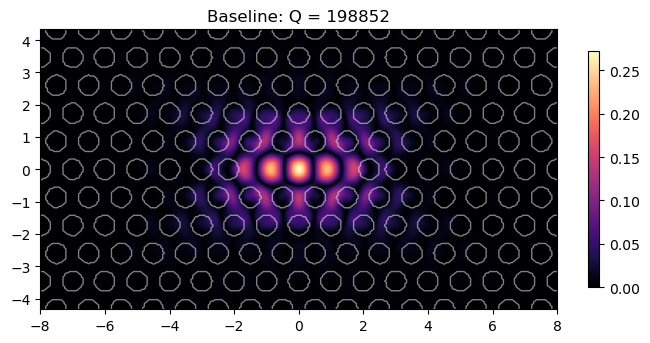

In [8]:
gmax = 2
truncate_g = 'tbt'
options = {'gmode_inds': [0], 'verbose': True, 'numeig': 10,
           'eig_sigma': f_target, 'gradients': 'approx', 'compute_im': False}

# Unoxidized cavity
phc_base = cavity_oxidized(0)
gme_base = legume.GuidedModeExp(phc_base, gmax=gmax, truncate_g=truncate_g)
gme_base.run(kpoints=np.array([[0], [0]]), **options)

# Identify the L3 cavity mode (first mode in bandgap)
print(f'\nModes near bandgap centre (bandgap: {f_lb:.4f} \u2013 {f_ub:.4f}):')
mode_idx = None
for i in range(gme_base.freqs.shape[1]):
    (freq_im_i, _, _) = gme_base.compute_rad(0, [i])
    Qi = gme_base.freqs[0, i] / (2 * freq_im_i[0])
    in_gap = f_lb < gme_base.freqs[0, i] < f_ub
    tag = ' <-- IN BANDGAP' if in_gap else ''
    print(f'  Mode {i}: f = {gme_base.freqs[0, i]:.5f},  Q = {Qi:.1f}{tag}')
    if in_gap and mode_idx is None:
        mode_idx = i

if mode_idx is None:
    raise RuntimeError('No mode found inside the bandgap')

(freq_im, _, _) = gme_base.compute_rad(0, [mode_idx])
Q_base = gme_base.freqs[0, mode_idx] / (2 * freq_im[0])
f_base = gme_base.freqs[0, mode_idx]
print(f'\nBaseline (no oxide): mode_idx = {mode_idx}, f = {f_base:.5f}, Q = {Q_base:.1f}')

ax = legume.viz.field(gme_base, 'e', 0, mode_idx, z=dslab/2,
                      component='y', val='abs', N1=300, N2=200)
plt.title(f'Baseline: Q = {Q_base:.0f}')
plt.show()

## Single oxidized run

13.243s total time for real part of frequencies in GuidedModeExp, of which
  0.230s (2%) for guided modes computation using the gmode_compute='exact' method
  1.050s (8%) for inverse matrix of Fourier-space permittivity
  8.768s (66%) for matrix diagionalization using the 'eigh' solver
  3.193s (24%) for creating GME matrix
Skipping imaginary part computation, use run_im() to run it, or compute_rad() to compute the radiative rates of selected eigenmodes
t_ox = 4.5 nm:  f = 0.26305,  Q = 57956.2
Change from baseline:  Δf = 0.00551,  ΔQ = -140895.7


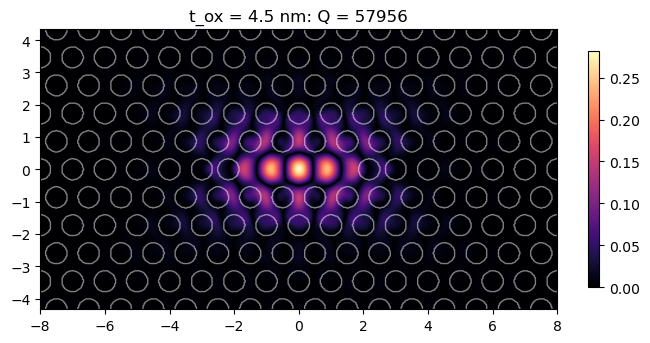

In [14]:
# Single oxidized run (t_ox = 5 nm)
t_ox_test = 4.5  # nm

mode_idx = 4
phc_ox = cavity_oxidized(t_ox_test, r_nm=75, consume_ratio=1.0)
gme_ox = legume.GuidedModeExp(phc_ox, gmax=gmax, truncate_g=truncate_g)
gme_ox.run(kpoints=np.array([[0], [0]]), **options)

(freq_im_ox, _, _) = gme_ox.compute_rad(0, [mode_idx])
Q_ox = gme_ox.freqs[0, mode_idx] / (2 * freq_im_ox[0])
f_ox = gme_ox.freqs[0, mode_idx]

print(f't_ox = {t_ox_test} nm:  f = {f_ox:.5f},  Q = {Q_ox:.1f}')
print(f'Change from baseline:  \u0394f = {f_ox - f_base:.5f},  \u0394Q = {Q_ox - Q_base:.1f}')

ax = legume.viz.field(gme_ox, 'e', 0, mode_idx, z=dslab/2,
                      component='y', val='abs', N1=500, N2=400)
plt.title(f't_ox = {t_ox_test} nm: Q = {Q_ox:.0f}')
plt.show()

## Q factor vs oxide thickness

In [9]:
# Sweep oxide thickness (consume_ratio = 0.5)
t_ox_values = np.linspace(0, 10, 4)  # nm
Qs_full = []
freqs_full = []

options_sweep = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
                 'gradients': 'approx', 'compute_im': False}

f_prev = f_base  # seed tracking with baseline L3 frequency

print('Sweeping oxide thickness (consume_ratio = 0.5):')
for t_ox_nm in t_ox_values:
    phc_s = cavity_oxidized(t_ox_nm)
    gme_s = legume.GuidedModeExp(phc_s, gmax=gmax, truncate_g=truncate_g)
    gme_s.run(kpoints=np.array([[0], [0]]), eig_sigma=f_prev, **options_sweep)

    # Q-based mode selection: find candidates near f_prev, pick closest frequency to f_prev
    all_freqs = gme_s.freqs[0, :]
    candidates = np.where(np.abs(all_freqs - f_prev) < 0.005)[0]
    mind = candidates[np.argmin(np.abs(all_freqs[candidates] - f_prev))] if len(candidates) > 0 else int(np.argmin(np.abs(all_freqs - f_prev)))
    (fim, _, _) = gme_s.compute_rad(0, [mind])
    best_Q = gme_s.freqs[0, mind] / (2 * fim[0])

    f_s = gme_s.freqs[0, mind]
    f_prev = f_s

    Qs_full.append(best_Q)
    freqs_full.append(f_s)
    print(f'  t_ox = {t_ox_nm:5.2f} nm,  Q = {best_Q:10.1f},  f = {f_s:.5f}  (mode {mind})')

print('Sweep complete.')

if SAVE_DATA:
    save_sweep('oxide_thickness', {
        't_ox_nm': t_ox_values,
        'Qs': np.array(Qs_full),
        'freqs': np.array(freqs_full),
    }, consume_ratio=0.5, r_nm=75)

Sweeping oxide thickness (consume_ratio = 0.5):
  t_ox =  0.00 nm,  Q =   198852.0,  f = 0.25754  (mode 8)
  t_ox =  3.33 nm,  Q =   181340.6,  f = 0.25908  (mode 8)
  t_ox =  6.67 nm,  Q =   156851.9,  f = 0.26071  (mode 8)
  t_ox = 10.00 nm,  Q =   129390.8,  f = 0.26244  (mode 8)
Sweep complete.
Results saved to data/2026-03-12_130411_oxide_thickness/


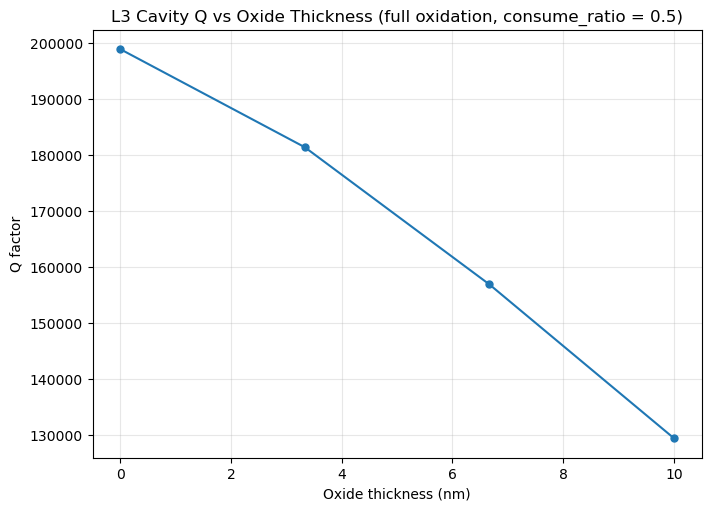

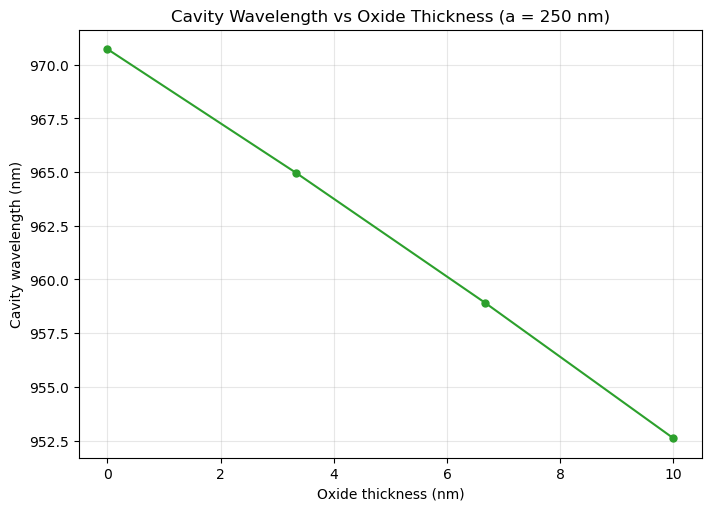

 t_ox (nm)           Q    f (norm)      λ (nm)
-----------------------------------------------------------------
      0.00    198852.0     0.25754       970.7
      3.33    181340.6     0.25908       965.0
      6.67    156851.9     0.26071       958.9
     10.00    129390.8     0.26244       952.6


In [10]:
# ── Plot full-oxidation sweep results ──────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(7, 5), constrained_layout=True)

ax1.plot(t_ox_values, Qs_full, 'o-', lw=1.5, markersize=5)
ax1.set_xlabel('Oxide thickness (nm)')
ax1.set_ylabel('Q factor')
ax1.set_title('L3 Cavity Q vs Oxide Thickness (full oxidation, consume_ratio = 0.5)')
ax1.grid(True, alpha=0.3)
plt.show()

# ── Wavelength conversion ──────────────────────────────────────────────────
lambdas_full_nm = [a_nm / f for f in freqs_full]

fig, ax2 = plt.subplots(figsize=(7, 5), constrained_layout=True)
ax2.plot(t_ox_values, lambdas_full_nm, 'o-', lw=1.5, markersize=5, color='tab:green')
ax2.set_xlabel('Oxide thickness (nm)')
ax2.set_ylabel('Cavity wavelength (nm)')
ax2.set_title(f'Cavity Wavelength vs Oxide Thickness (a = {a_nm} nm)')
ax2.grid(True, alpha=0.3)
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────
print('=' * 65)
print(f'{"t_ox (nm)":>10}  {"Q":>10}  {"f (norm)":>10}  {"λ (nm)":>10}')
print('-' * 65)
for t, q, f, lam in zip(t_ox_values, Qs_full, freqs_full, lambdas_full_nm):
    print(f'{t:>10.2f}  {q:>10.1f}  {f:>10.5f}  {lam:>10.1f}')
print('=' * 65)

## Combined sweep: Q vs oxide thickness for different hole radii

In [ ]:
# Combined sweep: oxide thickness for each hole radius
r_nm_list = [73, 74, 75, 76, 77]  # nm
t_ox_vals = np.linspace(0, 10, 21)  # nm
results = {}  # {r_nm: {'Qs': [...], 'freqs': [...]}}

options_sweep2 = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
                  'gradients': 'approx', 'compute_im': False}

for r_nm in r_nm_list:
    Qs, freqs = [], []
    f_prev = f_base  # re-seed for each radius

    print(f'\n--- r = {r_nm} nm ---')
    for t_ox_nm in t_ox_vals:
        phc_s = cavity_oxidized(t_ox_nm, r_nm=r_nm)
        gme_s = legume.GuidedModeExp(phc_s, gmax=gmax, truncate_g=truncate_g)
        gme_s.run(kpoints=np.array([[0], [0]]), eig_sigma=f_prev, **options_sweep2)

        # Q-based mode selection: find candidates near f_prev, pick closest frequency to f_prev
        all_freqs = gme_s.freqs[0, :]
        candidates = np.where(np.abs(all_freqs - f_prev) < 0.005)[0]
        mind = candidates[np.argmin(np.abs(all_freqs[candidates] - f_prev))] if len(candidates) > 0 else int(np.argmin(np.abs(all_freqs - f_prev)))
        (fim, _, _) = gme_s.compute_rad(0, [mind])
        best_Q = gme_s.freqs[0, mind] / (2 * fim[0])

        f_s = gme_s.freqs[0, mind]
        f_prev = f_s
        Qs.append(best_Q)
        freqs.append(f_s)
        print(f'  t_ox = {t_ox_nm:5.2f} nm,  Q = {best_Q:10.1f},  f = {f_s:.5f}  (mode {mind})')

    results[r_nm] = {'Qs': Qs, 'freqs': freqs}

print('\nCombined sweep complete.')

if SAVE_DATA:
    arrays = {'t_ox_nm': t_ox_vals, 'r_nm_list': np.array(r_nm_list)}
    for r_nm in r_nm_list:
        arrays[f'Qs_r{r_nm}'] = np.array(results[r_nm]['Qs'])
        arrays[f'freqs_r{r_nm}'] = np.array(results[r_nm]['freqs'])
    save_sweep('radius_oxide', arrays, consume_ratio=0.5, r_nm_list=r_nm_list)

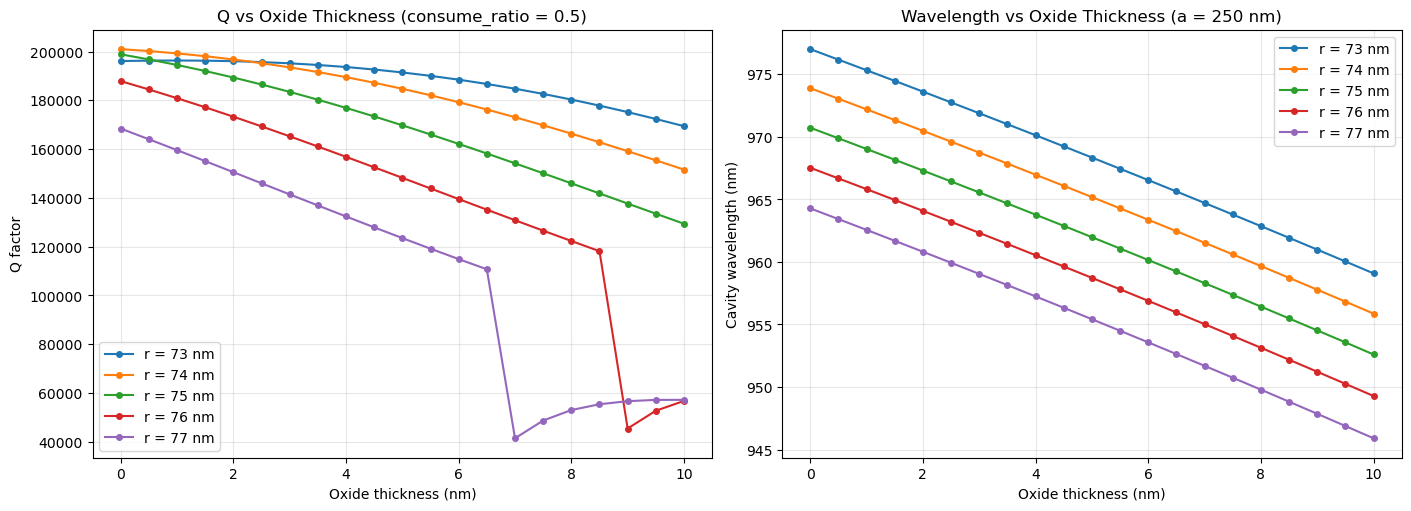

In [80]:
# ── Plot combined sweep results ────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

for r_nm in r_nm_list:
    ax1.plot(t_ox_vals, results[r_nm]['Qs'], 'o-', ms=4, lw=1.5,
             label=f'r = {r_nm} nm')
    lambdas = [a_nm / f for f in results[r_nm]['freqs']]
    ax2.plot(t_ox_vals, lambdas, 'o-', ms=4, lw=1.5,
             label=f'r = {r_nm} nm')

ax1.set_xlabel('Oxide thickness (nm)')
ax1.set_ylabel('Q factor')
ax1.set_title('Q vs Oxide Thickness (consume_ratio = 0.5)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Oxide thickness (nm)')
ax2.set_ylabel('Cavity wavelength (nm)')
ax2.set_title(f'Wavelength vs Oxide Thickness (a = {a_nm} nm)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.show()

## Sweep: Q vs oxide thickness for different consume ratios

In [15]:
# Combined sweep: oxide thickness for each consume_ratio (standard r = 75 nm)
cr_list = np.linspace(0, 1.0, 6)  # [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
t_ox_vals_cr = np.linspace(0, 10, 21)  # nm
results_cr = {}  # {cr: {'Qs': [...], 'freqs': [...]}}

options_sweep3 = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
                  'gradients': 'approx', 'compute_im': False}

for cr in cr_list:
    Qs, freqs = [], []
    f_prev = f_base

    print(f'\n--- consume_ratio = {cr:.2f} ---')
    for t_ox_nm in t_ox_vals_cr:
        phc_s = cavity_oxidized(t_ox_nm, consume_ratio=cr)
        gme_s = legume.GuidedModeExp(phc_s, gmax=gmax, truncate_g=truncate_g)
        gme_s.run(kpoints=np.array([[0], [0]]), eig_sigma=f_prev, **options_sweep3)

        # Q-based mode selection: find candidates near f_prev, pick closest frequency to f_prev
        all_freqs = gme_s.freqs[0, :]
        candidates = np.where(np.abs(all_freqs - f_prev) < 0.005)[0]
        mind = candidates[np.argmin(np.abs(all_freqs[candidates] - f_prev))] if len(candidates) > 0 else int(np.argmin(np.abs(all_freqs - f_prev)))
        (fim, _, _) = gme_s.compute_rad(0, [mind])
        best_Q = gme_s.freqs[0, mind] / (2 * fim[0])

        f_s = gme_s.freqs[0, mind]
        f_prev = f_s
        Qs.append(best_Q)
        freqs.append(f_s)
        print(f'  t_ox = {t_ox_nm:5.2f} nm,  Q = {best_Q:10.1f},  f = {f_s:.5f}  (mode {mind})')

    results_cr[cr] = {'Qs': Qs, 'freqs': freqs}

print('\nConsume ratio sweep complete.')

if SAVE_DATA:
    arrays = {'t_ox_nm': t_ox_vals_cr, 'cr_list': np.array(cr_list)}
    for cr in cr_list:
        arrays[f'Qs_cr{cr:.2f}'] = np.array(results_cr[cr]['Qs'])
        arrays[f'freqs_cr{cr:.2f}'] = np.array(results_cr[cr]['freqs'])
    save_sweep('consume_ratio_oxide', arrays, r_nm=75, cr_list=cr_list.tolist())


--- consume_ratio = 0.00 ---
  t_ox =  0.00 nm,  Q =   198852.0,  f = 0.25754  (mode 8)
  t_ox =  0.50 nm,  Q =   199606.5,  f = 0.25741  (mode 8)
  t_ox =  1.00 nm,  Q =   200286.1,  f = 0.25727  (mode 8)
  t_ox =  1.50 nm,  Q =   200892.0,  f = 0.25714  (mode 8)
  t_ox =  2.00 nm,  Q =   201425.5,  f = 0.25702  (mode 8)
  t_ox =  2.50 nm,  Q =   201888.1,  f = 0.25689  (mode 8)
  t_ox =  3.00 nm,  Q =   202281.5,  f = 0.25676  (mode 8)
  t_ox =  3.50 nm,  Q =   202607.7,  f = 0.25664  (mode 8)
  t_ox =  4.00 nm,  Q =   202868.6,  f = 0.25652  (mode 8)
  t_ox =  4.50 nm,  Q =   203066.5,  f = 0.25640  (mode 8)
  t_ox =  5.00 nm,  Q =   203203.6,  f = 0.25628  (mode 8)
  t_ox =  5.50 nm,  Q =   203282.4,  f = 0.25616  (mode 8)
  t_ox =  6.00 nm,  Q =   203305.3,  f = 0.25604  (mode 8)
  t_ox =  6.50 nm,  Q =   203274.8,  f = 0.25593  (mode 8)
  t_ox =  7.00 nm,  Q =   203193.6,  f = 0.25581  (mode 8)
  t_ox =  7.50 nm,  Q =   203064.3,  f = 0.25570  (mode 8)
  t_ox =  8.00 nm,  Q =   

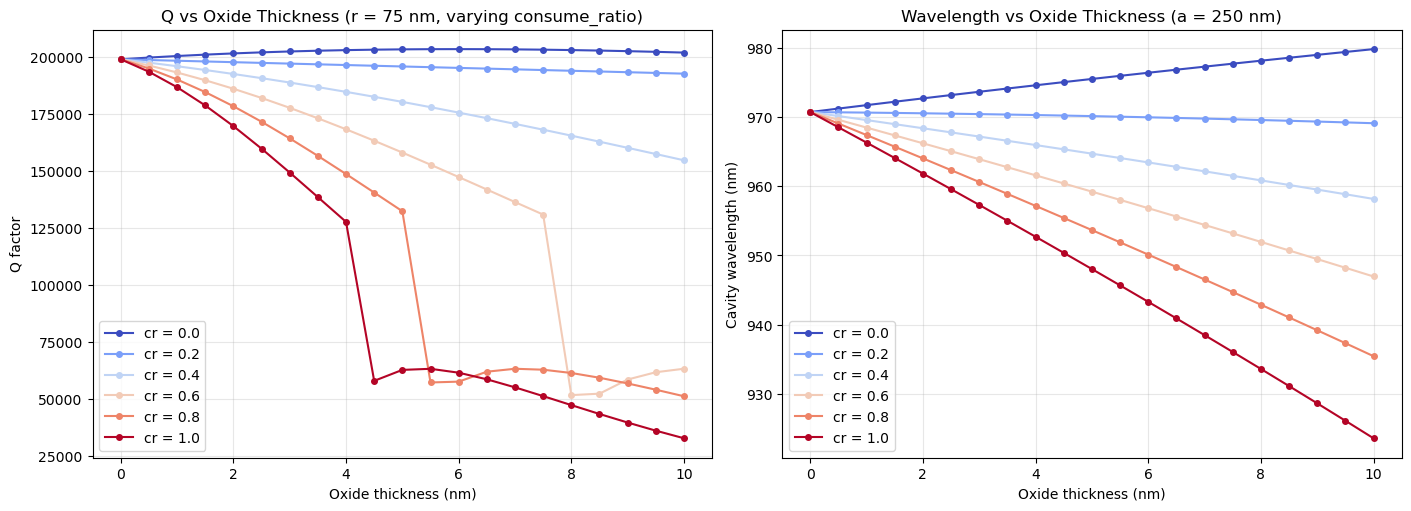

In [16]:
# ── Plot consume_ratio sweep results ───────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

cmap = plt.cm.coolwarm
colors = [cmap(i / (len(cr_list) - 1)) for i in range(len(cr_list))]

for i, cr in enumerate(cr_list):
    label = f'cr = {cr:.1f}'
    ax1.plot(t_ox_vals_cr, results_cr[cr]['Qs'], 'o-', ms=4, lw=1.5, label=label, color=colors[i])
    lambdas = [a_nm / f for f in results_cr[cr]['freqs']]
    ax2.plot(t_ox_vals_cr, lambdas, 'o-', ms=4, lw=1.5, label=label, color=colors[i])

ax1.set_xlabel('Oxide thickness (nm)')
ax1.set_ylabel('Q factor')
ax1.set_title('Q vs Oxide Thickness (r = 75 nm, varying consume_ratio)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Oxide thickness (nm)')
ax2.set_ylabel('Cavity wavelength (nm)')
ax2.set_title(f'Wavelength vs Oxide Thickness (a = {a_nm} nm)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.show()

## Sweep: Q vs oxide thickness for different end-hole shifts

In [18]:
# Combined sweep: oxide thickness for each end-hole shift (standard r = 75 nm, cr = 0.5)
dx_list = np.linspace(0.16, 0.2, 9)  # in units of a (~25–62.5 nm)
t_ox_vals_dx = np.linspace(0, 10, 21)  # nm
results_dx = {}  # {dx_val: {'Qs': [...], 'freqs': [...]}}

options_sweep4 = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
                  'gradients': 'approx', 'compute_im': False}

for dx_val in dx_list:
    Qs, freqs = [], []
    f_prev = f_base

    print(f'\n--- dx_shift = {dx_val:.4f}a ({dx_val * a_nm:.1f} nm) ---')
    for t_ox_nm in t_ox_vals_dx:
        phc_s = cavity_oxidized(t_ox_nm, dx_shift=dx_val)
        gme_s = legume.GuidedModeExp(phc_s, gmax=gmax, truncate_g=truncate_g)
        gme_s.run(kpoints=np.array([[0], [0]]), eig_sigma=f_prev, **options_sweep4)

        # Q-based mode selection: find candidates near f_prev, pick closest frequency to f_prev
        all_freqs = gme_s.freqs[0, :]
        candidates = np.where(np.abs(all_freqs - f_prev) < 0.005)[0]
        mind = candidates[np.argmin(np.abs(all_freqs[candidates] - f_prev))] if len(candidates) > 0 else int(np.argmin(np.abs(all_freqs - f_prev)))
        (fim, _, _) = gme_s.compute_rad(0, [mind])
        best_Q = gme_s.freqs[0, mind] / (2 * fim[0])

        f_s = gme_s.freqs[0, mind]
        f_prev = f_s
        Qs.append(best_Q)
        freqs.append(f_s)
        print(f'  t_ox = {t_ox_nm:5.2f} nm,  Q = {best_Q:10.1f},  f = {f_s:.5f}  (mode {mind})')

    results_dx[dx_val] = {'Qs': Qs, 'freqs': freqs}

print('\nEnd-hole shift sweep complete.')

if SAVE_DATA:
    arrays = {'t_ox_nm': t_ox_vals_dx, 'dx_list': np.array(dx_list)}
    for dx_val in dx_list:
        arrays[f'Qs_dx{dx_val:.4f}'] = np.array(results_dx[dx_val]['Qs'])
        arrays[f'freqs_dx{dx_val:.4f}'] = np.array(results_dx[dx_val]['freqs'])
    save_sweep('dx_shift_oxide_smallShift', arrays,
               consume_ratio=0.5, r_nm=75,
               dx_list_a=[f'{d:.4f}' for d in dx_list],
               dx_list_nm=[f'{d*a_nm:.1f}' for d in dx_list])


--- dx_shift = 0.1600a (40.0 nm) ---
  t_ox =  0.00 nm,  Q =   106142.1,  f = 0.25766  (mode 8)
  t_ox =  0.50 nm,  Q =   107262.3,  f = 0.25789  (mode 8)
  t_ox =  1.00 nm,  Q =   108411.0,  f = 0.25811  (mode 8)
  t_ox =  1.50 nm,  Q =   109587.1,  f = 0.25834  (mode 8)
  t_ox =  2.00 nm,  Q =   110789.5,  f = 0.25857  (mode 8)
  t_ox =  2.50 nm,  Q =   112016.9,  f = 0.25880  (mode 8)
  t_ox =  3.00 nm,  Q =   113267.8,  f = 0.25904  (mode 8)
  t_ox =  3.50 nm,  Q =   114540.2,  f = 0.25928  (mode 8)
  t_ox =  4.00 nm,  Q =   115832.2,  f = 0.25951  (mode 8)
  t_ox =  4.50 nm,  Q =   117141.4,  f = 0.25975  (mode 8)
  t_ox =  5.00 nm,  Q =   118465.1,  f = 0.26000  (mode 8)
  t_ox =  5.50 nm,  Q =   119800.3,  f = 0.26024  (mode 8)
  t_ox =  6.00 nm,  Q =   121143.6,  f = 0.26049  (mode 8)
  t_ox =  6.50 nm,  Q =   122491.3,  f = 0.26074  (mode 8)
  t_ox =  7.00 nm,  Q =   123839.5,  f = 0.26099  (mode 8)
  t_ox =  7.50 nm,  Q =   125183.5,  f = 0.26124  (mode 8)
  t_ox =  8.00 nm,

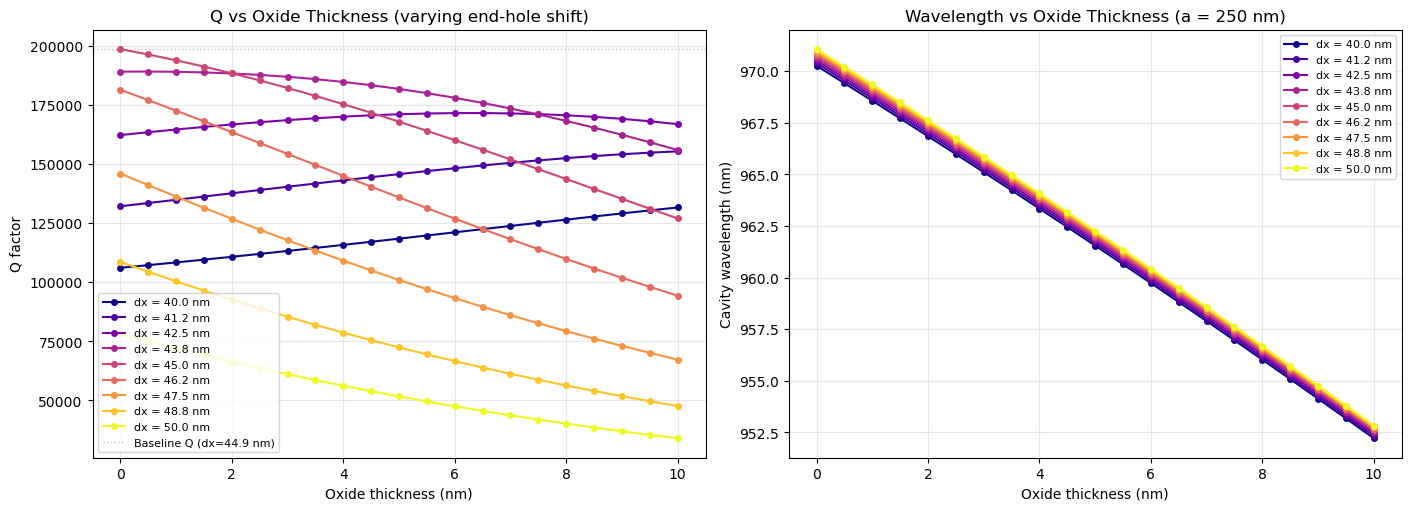

In [24]:
# ── Plot end-hole shift sweep results ──────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

cmap = plt.cm.plasma
colors = [cmap(i / (len(dx_list) - 1)) for i in range(len(dx_list))]

for i, dx_val in enumerate(dx_list):
    label = f'dx = {dx_val*a_nm:.1f} nm'
    ax1.plot(t_ox_vals_dx, results_dx[dx_val]['Qs'], 'o-', ms=4, lw=1.5, label=label, color=colors[i])
    lambdas = [a_nm / f for f in results_dx[dx_val]['freqs']]
    ax2.plot(t_ox_vals_dx, lambdas, 'o-', ms=4, lw=1.5, label=label, color=colors[i])

ax1.axhline(Q_base, color='gray', ls=':', lw=1, alpha=0.5, label=f'Baseline Q (dx={dx_opt*a_nm:.1f} nm)')
ax1.set_xlabel('Oxide thickness (nm)')
ax1.set_ylabel('Q factor')
ax1.set_title('Q vs Oxide Thickness (varying end-hole shift)')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Oxide thickness (nm)')
ax2.set_ylabel('Cavity wavelength (nm)')
ax2.set_title(f'Wavelength vs Oxide Thickness (a = {a_nm} nm)')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.show()

## Non-uniform oxide: random per-hole variation

In [9]:
def cavity_oxidized_random(t_ox_base_nm, sigma=0.0, seed=None,
                           consume_ratio=0.5, r_nm=None, dx_shift=None):
    """Build L3 cavity with random per-hole oxide thickness variation.

    Each hole's sidewall oxide thickness is drawn from a normal distribution
    around the base value. Top/bottom oxide films stay uniform.

    Parameters
    ----------
    t_ox_base_nm : float
        Mean oxide thickness in nm. Set to 0 for unoxidized cavity.
    sigma : float
        Relative std dev of per-hole oxide thickness.
        0 = uniform, 0.1 = 10% variation, etc.
    seed : int or None
        Random seed for reproducibility.
    consume_ratio : float
        Fraction of oxide replacing GaAs (0-1). Default 0.5.
    r_nm : float or None
        Hole radius in nm. If None, uses global `ra`.
    dx_shift : float or None
        End-hole shift in units of a. If None, uses global `dx_opt`.

    Returns
    -------
    phc : legume.PhotCryst
    t_ox_per_hole : np.ndarray of shape (nc,), per-hole oxide in nm
    """
    r_a = (r_nm / a_nm) if r_nm is not None else ra
    dx_local = dx.copy()
    if dx_shift is not None:
        dx_local[0] = dx_shift

    # Generate per-hole oxide thicknesses
    if sigma > 0 and t_ox_base_nm > 0:
        rng = np.random.default_rng(seed)
        t_ox_per_hole = t_ox_base_nm * (1 + sigma * rng.standard_normal(nc))
        t_ox_per_hole = np.clip(t_ox_per_hole, 0, None)
    else:
        t_ox_per_hole = np.full(nc, t_ox_base_nm)

    # Base oxide for uniform layers (top/bottom films, slab thinning)
    t_ox_base = t_ox_base_nm / a_nm

    if t_ox_base_nm > 0:
        d_consume = consume_ratio * t_ox_base
        d_slab_eff = dslab - 2 * d_consume
        if d_slab_eff <= 0:
            raise ValueError(
                f'Oxide consumes entire slab: 2*{consume_ratio}*{t_ox_base_nm} nm '
                f'>= dslab = {dslab * a_nm} nm')
    else:
        d_slab_eff = dslab

    phc = legume.PhotCryst(lattice)

    if t_ox_base_nm > 0:
        phc.add_layer(d=t_ox_base, eps_b=eps_oxide)       # bottom oxide
        phc.add_layer(d=d_slab_eff, eps_b=n_slab**2)      # thinned GaAs
        phc.add_layer(d=t_ox_base, eps_b=eps_oxide)        # top oxide
    else:
        phc.add_layer(d=dslab, eps_b=n_slab**2)

    slab_idx = 1 if t_ox_base_nm > 0 else 0

    for ic in range(nc):
        yc = yp[ic]
        xc = xp[ic] + dx_local[ic] if xp[ic] != 0 else 0.0

        positions = [(xc, yc)]
        if nx-0.6 > xp[ic] > 0 and (ny-1.1)*np.sqrt(3)/2 > yp[ic] > 0:
            positions.append((-xc, -yc))
        if nx-1.6 > xp[ic] > 0:
            positions.append((-xc, yc))
        if (ny-1.1)*np.sqrt(3)/2 > yp[ic] > 0 and nx-1.1 > xp[ic]:
            positions.append((xc, -yc))

        for (px, py) in positions:
            if t_ox_base_nm > 0:
                # Per-hole oxide ring dimensions
                t_ic = t_ox_per_hole[ic] / a_nm
                r_outer_ic = r_a + consume_ratio * t_ic
                r_inner_ic = max(r_a - (1 - consume_ratio) * t_ic, 0.001)

                phc.add_shape(Ring(eps=eps_oxide, r_i=r_inner_ic, r_o=r_outer_ic,
                                  x_cent=px, y_cent=py), layer=slab_idx)
                phc.add_shape(Circle(eps=1.0, r=r_inner_ic,
                                    x_cent=px, y_cent=py), layer=slab_idx)
                phc.add_shape(Circle(eps=1.0, r=r_outer_ic,
                                    x_cent=px, y_cent=py), layer=0)
                phc.add_shape(Circle(eps=1.0, r=r_outer_ic,
                                    x_cent=px, y_cent=py), layer=2)
            else:
                phc.add_shape(Circle(x_cent=px, y_cent=py, r=r_a))

    return phc, t_ox_per_hole

In [10]:
# Sigma sweep: how does random per-hole oxide variation affect Q?
# Fixed t_ox_base = 4 nm, varying sigma (relative std dev), N_trials per sigma
t_ox_base_rand = 4.0  # nm
sigma_values = np.linspace(0, 0.5, 11)
N_trials = 10

options_rand = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
                'gradients': 'approx', 'compute_im': False}

# Store all Q values: shape (len(sigma_values), N_trials)
Q_all = np.zeros((len(sigma_values), N_trials))

print(f'Sigma sweep: t_ox_base = {t_ox_base_rand} nm, {N_trials} trials per sigma')
for si, sigma in enumerate(sigma_values):
    print(f'\n--- sigma = {sigma:.2f} ({sigma*100:.0f}% variation) ---')
    for trial in range(N_trials):
        seed = si * 1000 + trial
        phc_r, t_ox_arr = cavity_oxidized_random(t_ox_base_rand, sigma=sigma, seed=seed)
        gme_r = legume.GuidedModeExp(phc_r, gmax=gmax, truncate_g=truncate_g)
        gme_r.run(kpoints=np.array([[0], [0]]), eig_sigma=f_base, **options_rand)

        # Q-based mode selection
        all_freqs = gme_r.freqs[0, :]
        candidates = np.where(np.abs(all_freqs - f_base) < 0.005)[0]
        mind = candidates[np.argmin(np.abs(all_freqs[candidates] - f_base))] if len(candidates) > 0 else int(np.argmin(np.abs(all_freqs - f_base)))
        (fim, _, _) = gme_r.compute_rad(0, [mind])
        best_Q = gme_r.freqs[0, mind] / (2 * fim[0])

        Q_all[si, trial] = best_Q
        print(f'  trial {trial}: Q = {best_Q:.0f}  (t_ox range: {t_ox_arr.min():.2f}-{t_ox_arr.max():.2f} nm)')

# Compute statistics
Q_mean = Q_all.mean(axis=1)
Q_std = Q_all.std(axis=1)
Q_min = Q_all.min(axis=1)
Q_max = Q_all.max(axis=1)

print(f'\nSigma sweep complete. {len(sigma_values) * N_trials} total runs.')

if SAVE_DATA:
    save_sweep('random_oxide_sigma', {
        'sigma_values': sigma_values,
        'Q_all': Q_all,
        'Q_mean': Q_mean,
        'Q_std': Q_std,
        'Q_min': Q_min,
        'Q_max': Q_max,
    }, t_ox_base_nm=t_ox_base_rand, N_trials=N_trials, consume_ratio=0.5)

Sigma sweep: t_ox_base = 4.0 nm, 10 trials per sigma

--- sigma = 0.00 (0% variation) ---
  trial 0: Q = 176896  (t_ox range: 4.00-4.00 nm)
  trial 1: Q = 176896  (t_ox range: 4.00-4.00 nm)
  trial 2: Q = 176896  (t_ox range: 4.00-4.00 nm)
  trial 3: Q = 176896  (t_ox range: 4.00-4.00 nm)
  trial 4: Q = 176896  (t_ox range: 4.00-4.00 nm)
  trial 5: Q = 176896  (t_ox range: 4.00-4.00 nm)
  trial 6: Q = 176896  (t_ox range: 4.00-4.00 nm)
  trial 7: Q = 176896  (t_ox range: 4.00-4.00 nm)
  trial 8: Q = 176896  (t_ox range: 4.00-4.00 nm)
  trial 9: Q = 176896  (t_ox range: 4.00-4.00 nm)

--- sigma = 0.05 (5% variation) ---
  trial 0: Q = 176510  (t_ox range: 3.69-4.39 nm)
  trial 1: Q = 176715  (t_ox range: 3.62-4.42 nm)
  trial 2: Q = 176009  (t_ox range: 3.48-4.35 nm)
  trial 3: Q = 177000  (t_ox range: 3.57-4.38 nm)
  trial 4: Q = 176099  (t_ox range: 3.59-4.33 nm)
  trial 5: Q = 182899  (t_ox range: 3.60-4.39 nm)
  trial 6: Q = 175508  (t_ox range: 3.55-4.36 nm)
  trial 7: Q = 183328  

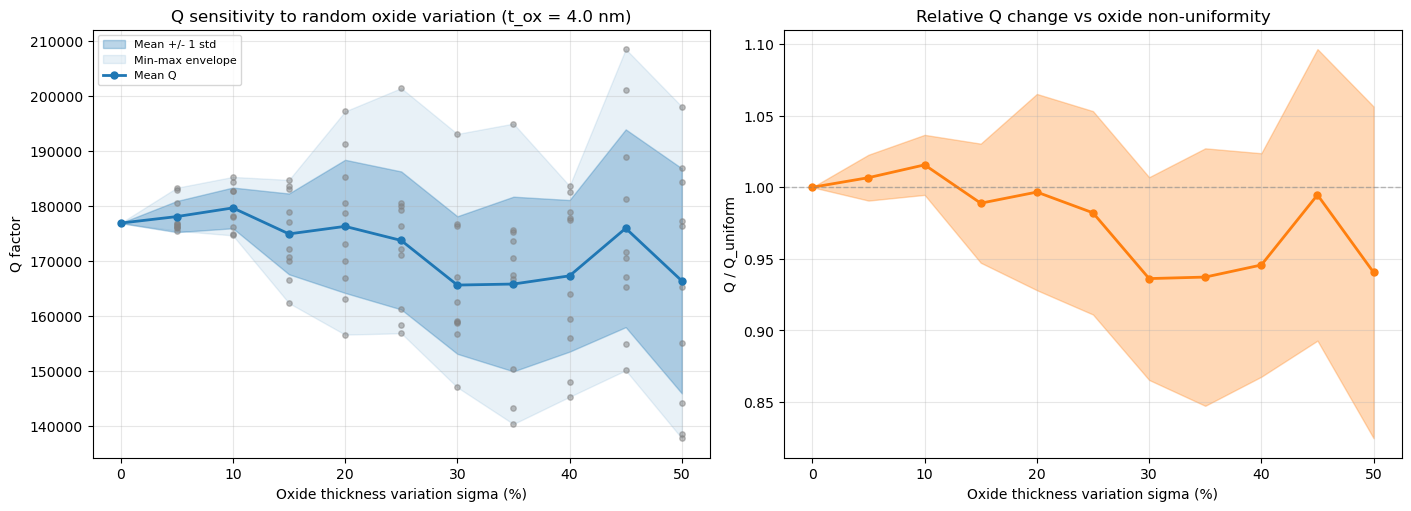

 sigma (%)        Mean Q         Std Q         Min Q         Max Q   Q/Q_uni
------------------------------------------------------------------------
         0        176896             0        176896        176896     1.000
         5        178082          2830        175508        183328     1.007
        10        179662          3707        174654        185305     1.016
        15        174928          7356        162325        184758     0.989
        20        176302         12119        156589        197230     0.997
        25        173738         12562        156842        201474     0.982
        30        165615         12523        146997        193130     0.936
        35        165801         15903        140311        195010     0.937
        40        167295         13802        145263        183668     0.946
        45        175954         18006        150088        208573     0.995
        50        166376         20487        137720        198107     0.941


In [11]:
# ── Plot sigma sweep results ───────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# Left: mean +/- std with scatter of all trials
sigma_pct = sigma_values * 100
ax1.fill_between(sigma_pct, Q_mean - Q_std, Q_mean + Q_std, alpha=0.3, color='tab:blue', label='Mean +/- 1 std')
ax1.fill_between(sigma_pct, Q_min, Q_max, alpha=0.1, color='tab:blue', label='Min-max envelope')
ax1.plot(sigma_pct, Q_mean, 'o-', ms=5, lw=2, color='tab:blue', label='Mean Q', zorder=5)

# Scatter all individual trials
for si in range(len(sigma_values)):
    ax1.scatter([sigma_pct[si]] * N_trials, Q_all[si, :], s=15, c='gray', alpha=0.5, zorder=4)

ax1.set_xlabel('Oxide thickness variation sigma (%)')
ax1.set_ylabel('Q factor')
ax1.set_title(f'Q sensitivity to random oxide variation (t_ox = {t_ox_base_rand} nm)')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Right: relative Q change from uniform
Q_uniform = Q_mean[0]  # sigma=0 is uniform
ax2.fill_between(sigma_pct, (Q_mean - Q_std) / Q_uniform, (Q_mean + Q_std) / Q_uniform,
                 alpha=0.3, color='tab:orange')
ax2.plot(sigma_pct, Q_mean / Q_uniform, 'o-', ms=5, lw=2, color='tab:orange')
ax2.axhline(1.0, color='gray', ls='--', lw=1, alpha=0.5)
ax2.set_xlabel('Oxide thickness variation sigma (%)')
ax2.set_ylabel('Q / Q_uniform')
ax2.set_title('Relative Q change vs oxide non-uniformity')
ax2.grid(True, alpha=0.3)

plt.show()

# Summary table
print(f'{"sigma (%)":>10}  {"Mean Q":>12}  {"Std Q":>12}  {"Min Q":>12}  {"Max Q":>12}  {"Q/Q_uni":>8}')
print('-' * 72)
for si, sigma in enumerate(sigma_values):
    print(f'{sigma*100:>10.0f}  {Q_mean[si]:>12.0f}  {Q_std[si]:>12.0f}  {Q_min[si]:>12.0f}  {Q_max[si]:>12.0f}  {Q_mean[si]/Q_uniform:>8.3f}')

In [13]:
# 2D sweep: oxide thickness x sigma, with error bands from multiple trials
sigma_list_2d = [0, 0.1, 0.2, 0.3]
t_ox_vals_2d = np.linspace(0, 10, 21)  # nm
N_trials_2d = 5
results_2d = {}  # {sigma: {'Q_mean': [...], 'Q_std': [...], 'freqs_mean': [...]}}

options_rand2 = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
                 'gradients': 'approx', 'compute_im': False}

for sigma in sigma_list_2d:
    Q_trials = np.zeros((len(t_ox_vals_2d), N_trials_2d))
    f_trials = np.zeros((len(t_ox_vals_2d), N_trials_2d))

    print(f'\n--- sigma = {sigma:.1f} ({sigma*100:.0f}% variation) ---')
    for trial in range(N_trials_2d):
        f_prev = f_base
        for ti, t_ox_nm in enumerate(t_ox_vals_2d):
            seed = int(sigma * 10000) + trial * 100 + ti
            phc_r, _ = cavity_oxidized_random(t_ox_nm, sigma=sigma, seed=seed)
            gme_r = legume.GuidedModeExp(phc_r, gmax=gmax, truncate_g=truncate_g)
            gme_r.run(kpoints=np.array([[0], [0]]), eig_sigma=f_prev, **options_rand2)

            all_freqs = gme_r.freqs[0, :]
            candidates = np.where(np.abs(all_freqs - f_prev) < 0.005)[0]
            mind = candidates[np.argmin(np.abs(all_freqs[candidates] - f_prev))] if len(candidates) > 0 else int(np.argmin(np.abs(all_freqs - f_prev)))
            (fim, _, _) = gme_r.compute_rad(0, [mind])
            best_Q = gme_r.freqs[0, mind] / (2 * fim[0])

            Q_trials[ti, trial] = best_Q
            f_trials[ti, trial] = gme_r.freqs[0, mind]
            f_prev = gme_r.freqs[0, mind]

        print(f'  trial {trial} done')

    results_2d[sigma] = {
        'Q_mean': Q_trials.mean(axis=1),
        'Q_std': Q_trials.std(axis=1),
        'freqs_mean': f_trials.mean(axis=1),
        'Q_all': Q_trials,
    }

print('\n2D sweep complete.')

if SAVE_DATA:
    arrays = {'t_ox_nm': t_ox_vals_2d, 'sigma_list': np.array(sigma_list_2d)}
    for sigma in sigma_list_2d:
        arrays[f'Q_mean_s{sigma:.1f}'] = results_2d[sigma]['Q_mean']
        arrays[f'Q_std_s{sigma:.1f}'] = results_2d[sigma]['Q_std']
        arrays[f'freqs_mean_s{sigma:.1f}'] = results_2d[sigma]['freqs_mean']
        arrays[f'Q_all_s{sigma:.1f}'] = results_2d[sigma]['Q_all']
    save_sweep('random_oxide_2d', arrays,
               N_trials=N_trials_2d, consume_ratio=0.5, sigma_list=sigma_list_2d)


--- sigma = 0.0 (0% variation) ---
  trial 0 done
  trial 1 done
  trial 2 done
  trial 3 done
  trial 4 done

--- sigma = 0.1 (10% variation) ---
  trial 0 done
  trial 1 done
  trial 2 done
  trial 3 done
  trial 4 done

--- sigma = 0.2 (20% variation) ---
  trial 0 done
  trial 1 done
  trial 2 done
  trial 3 done
  trial 4 done

--- sigma = 0.3 (30% variation) ---
  trial 0 done
  trial 1 done
  trial 2 done
  trial 3 done
  trial 4 done

2D sweep complete.
Results saved to data/2026-03-27_003413_random_oxide_2d/


Loading from data/2026-03-27_003413_random_oxide_2d


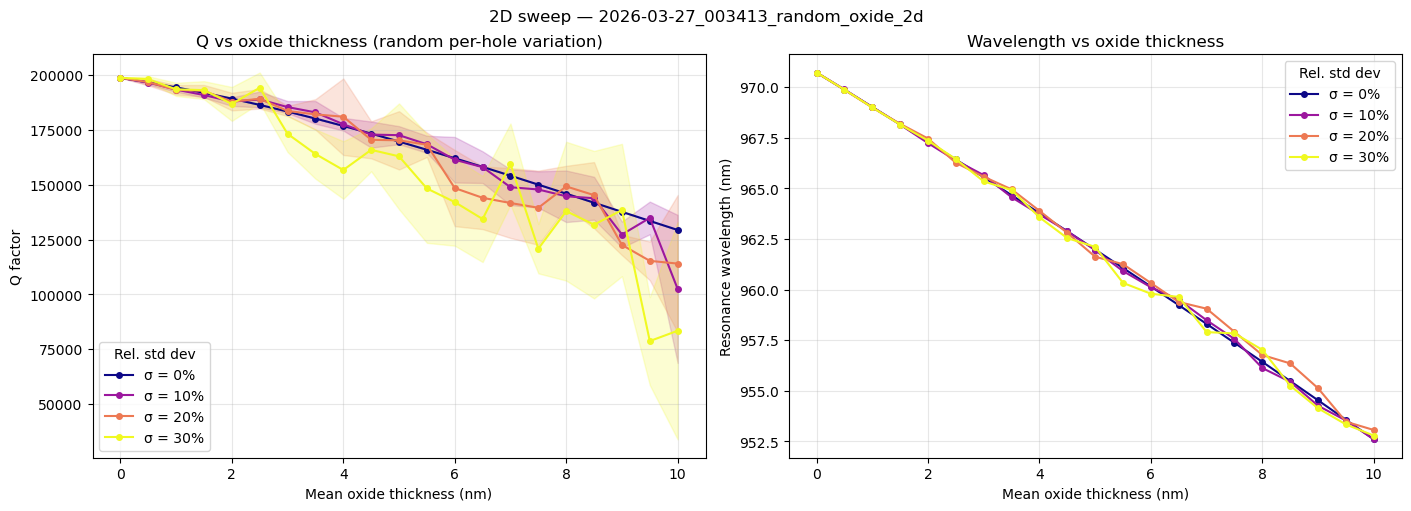

In [9]:
# ── Plot 2D sweep results: Q vs t_ox for each sigma ────────────────────────
import os, glob

# Load from most recent saved folder
folders = sorted(glob.glob("data/*_random_oxide_2d"))
assert folders, "No random_oxide_2d data found — run the sweep first."
data_dir = folders[-1]
print(f"Loading from {data_dir}")

t_ox_nm_2d = np.load(f"{data_dir}/t_ox_nm.npy")
sigma_list_loaded = np.load(f"{data_dir}/sigma_list.npy")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
cmap = plt.cm.plasma
colors = [cmap(i / max(len(sigma_list_loaded) - 1, 1)) for i in range(len(sigma_list_loaded))]

for idx, sigma in enumerate(sigma_list_loaded):
    Q_mean = np.load(f"{data_dir}/Q_mean_s{sigma:.1f}.npy")
    Q_std  = np.load(f"{data_dir}/Q_std_s{sigma:.1f}.npy")
    freqs  = np.load(f"{data_dir}/freqs_mean_s{sigma:.1f}.npy")
    c = colors[idx]
    label = f"σ = {sigma:.0%}"
    ax1.fill_between(t_ox_nm_2d, Q_mean - Q_std, Q_mean + Q_std, alpha=0.2, color=c)
    ax1.plot(t_ox_nm_2d, Q_mean, "o-", ms=4, lw=1.5, color=c, label=label)
    ax2.plot(t_ox_nm_2d, a_nm / freqs, "o-", ms=4, lw=1.5, color=c, label=label)

ax1.set_xlabel("Mean oxide thickness (nm)")
ax1.set_ylabel("Q factor")
ax1.set_title("Q vs oxide thickness (random per-hole variation)")
ax1.legend(title="Rel. std dev")
ax1.grid(True, alpha=0.3)

ax2.set_xlabel("Mean oxide thickness (nm)")
ax2.set_ylabel("Resonance wavelength (nm)")
ax2.set_title("Wavelength vs oxide thickness")
ax2.legend(title="Rel. std dev")
ax2.grid(True, alpha=0.3)

plt.suptitle(f"2D sweep — {os.path.basename(data_dir)}")
plt.show()

# Q factor vs hole radius

In [81]:
""" # Sweep hole radius (no oxide)
ra_orig = ra  # save original value
r_nm_values = np.linspace(73, 77, 21)  # nm
Qs_r = []
freqs_r = []

options_r = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
             'gradients': 'approx', 'compute_im': False}

f_prev_r = f_base  # seed tracking with baseline L3 frequency

print('Sweeping hole radius:')
for r_nm in r_nm_values:
    ra = r_nm / a_nm  # update global ra

    phc_r = cavity_oxidized(0)
    gme_r = legume.GuidedModeExp(phc_r, gmax=gmax, truncate_g=truncate_g)
    gme_r.run(kpoints=np.array([[0], [0]]), eig_sigma=f_prev_r, **options_r)

    # Track the L3 mode by frequency continuity
    all_freqs_r = gme_r.freqs[0, :]
    mind_r = int(np.argmin(np.abs(all_freqs_r - f_prev_r)))

    (freq_im_r, _, _) = gme_r.compute_rad(0, [mind_r])
    Q_r = gme_r.freqs[0, mind_r] / (2 * freq_im_r[0])
    f_r = gme_r.freqs[0, mind_r]

    f_prev_r = f_r  # update reference for next step

    Qs_r.append(Q_r)
    freqs_r.append(f_r)
    print(f'  r = {r_nm:5.1f} nm (ra = {ra:.4f}),  Q = {Q_r:10.1f},  f = {f_r:.5f}  (mode {mind_r})')

ra = ra_orig  # restore original ra
print('Sweep complete.') """

" # Sweep hole radius (no oxide)\nra_orig = ra  # save original value\nr_nm_values = np.linspace(73, 77, 21)  # nm\nQs_r = []\nfreqs_r = []\n\noptions_r = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,\n             'gradients': 'approx', 'compute_im': False}\n\nf_prev_r = f_base  # seed tracking with baseline L3 frequency\n\nprint('Sweeping hole radius:')\nfor r_nm in r_nm_values:\n    ra = r_nm / a_nm  # update global ra\n\n    phc_r = cavity_oxidized(0)\n    gme_r = legume.GuidedModeExp(phc_r, gmax=gmax, truncate_g=truncate_g)\n    gme_r.run(kpoints=np.array([[0], [0]]), eig_sigma=f_prev_r, **options_r)\n\n    # Track the L3 mode by frequency continuity\n    all_freqs_r = gme_r.freqs[0, :]\n    mind_r = int(np.argmin(np.abs(all_freqs_r - f_prev_r)))\n\n    (freq_im_r, _, _) = gme_r.compute_rad(0, [mind_r])\n    Q_r = gme_r.freqs[0, mind_r] / (2 * freq_im_r[0])\n    f_r = gme_r.freqs[0, mind_r]\n\n    f_prev_r = f_r  # update reference for next step\n\n    Qs_r.append(Q_r)\n    

In [82]:
""" # ── Plot radius sweep results ──────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(7, 5), constrained_layout=True)

# Q vs hole radius
ax1.plot(r_nm_values, Qs_r, 'o-', lw=1.5, markersize=5)
ax1.axvline(75, color='gray', ls='--', lw=1, alpha=0.5, label='Nominal (75 nm)')
ax1.set_xlabel('Hole radius (nm)')
ax1.set_ylabel('Q factor')
ax1.set_title('L3 Cavity Q vs Hole Radius')
ax1.legend()
ax1.grid(True, alpha=0.3)


plt.show()

# ── Wavelength conversion ──────────────────────────────────────────────────
lambdas_r_nm = [a_nm / f for f in freqs_r]

fig, ax3 = plt.subplots(figsize=(7, 5), constrained_layout=True)
ax3.plot(r_nm_values, lambdas_r_nm, 'o-', lw=1.5, markersize=5, color='tab:green')
ax3.axvline(75, color='gray', ls='--', lw=1, alpha=0.5, label='Nominal (75 nm)')
ax3.set_xlabel('Hole radius (nm)')
ax3.set_ylabel('Cavity wavelength (nm)')
ax3.set_title(f'Cavity Wavelength vs Hole Radius (a = {a_nm} nm)')
ax3.legend()
ax3.grid(True, alpha=0.3)
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────
print('=' * 65)
print(f'{"r (nm)":>10}  {"Q":>10}  {"f (norm)":>10}  {"λ (nm)":>10}')
print('-' * 65)
for r, q, f, lam in zip(r_nm_values, Qs_r, freqs_r, lambdas_r_nm):
    print(f'{r:>10.1f}  {q:>10.1f}  {f:>10.5f}  {lam:>10.1f}')
print('=' * 65)

 """

' # ── Plot radius sweep results ──────────────────────────────────────────────\nfig, ax1 = plt.subplots(figsize=(7, 5), constrained_layout=True)\n\n# Q vs hole radius\nax1.plot(r_nm_values, Qs_r, \'o-\', lw=1.5, markersize=5)\nax1.axvline(75, color=\'gray\', ls=\'--\', lw=1, alpha=0.5, label=\'Nominal (75 nm)\')\nax1.set_xlabel(\'Hole radius (nm)\')\nax1.set_ylabel(\'Q factor\')\nax1.set_title(\'L3 Cavity Q vs Hole Radius\')\nax1.legend()\nax1.grid(True, alpha=0.3)\n\n\nplt.show()\n\n# ── Wavelength conversion ──────────────────────────────────────────────────\nlambdas_r_nm = [a_nm / f for f in freqs_r]\n\nfig, ax3 = plt.subplots(figsize=(7, 5), constrained_layout=True)\nax3.plot(r_nm_values, lambdas_r_nm, \'o-\', lw=1.5, markersize=5, color=\'tab:green\')\nax3.axvline(75, color=\'gray\', ls=\'--\', lw=1, alpha=0.5, label=\'Nominal (75 nm)\')\nax3.set_xlabel(\'Hole radius (nm)\')\nax3.set_ylabel(\'Cavity wavelength (nm)\')\nax3.set_title(f\'Cavity Wavelength vs Hole Radius (a = {a_nm}